#Installing Libraries

In [1]:
!pip install ultralytics roboflow opencv-python-headless numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 96.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


#Dataset

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="H3HMUHVce0r0znxVkALK")
project = rf.workspace("jadon").project("drone-landing-pad-recognition")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Drone-Landing-Pad-Recognition-1 in yolov8:: 100%|██████████| 3005/3005 [00:00<00:00, 5988.51it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#Training

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    project="Aethrone_Landing",
    name="landing_pad_model"
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Drone-Landing-Pad-Recognition-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=landing_pad_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cad6325b0e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

#Finding the path

In [7]:
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

weight_files = glob.glob("**/best.pt", recursive=True)

print(best_weight_path)

runs/detect/Aethrone_Landing/landing_pad_model/weights/best.pt


#Testing on 4 images

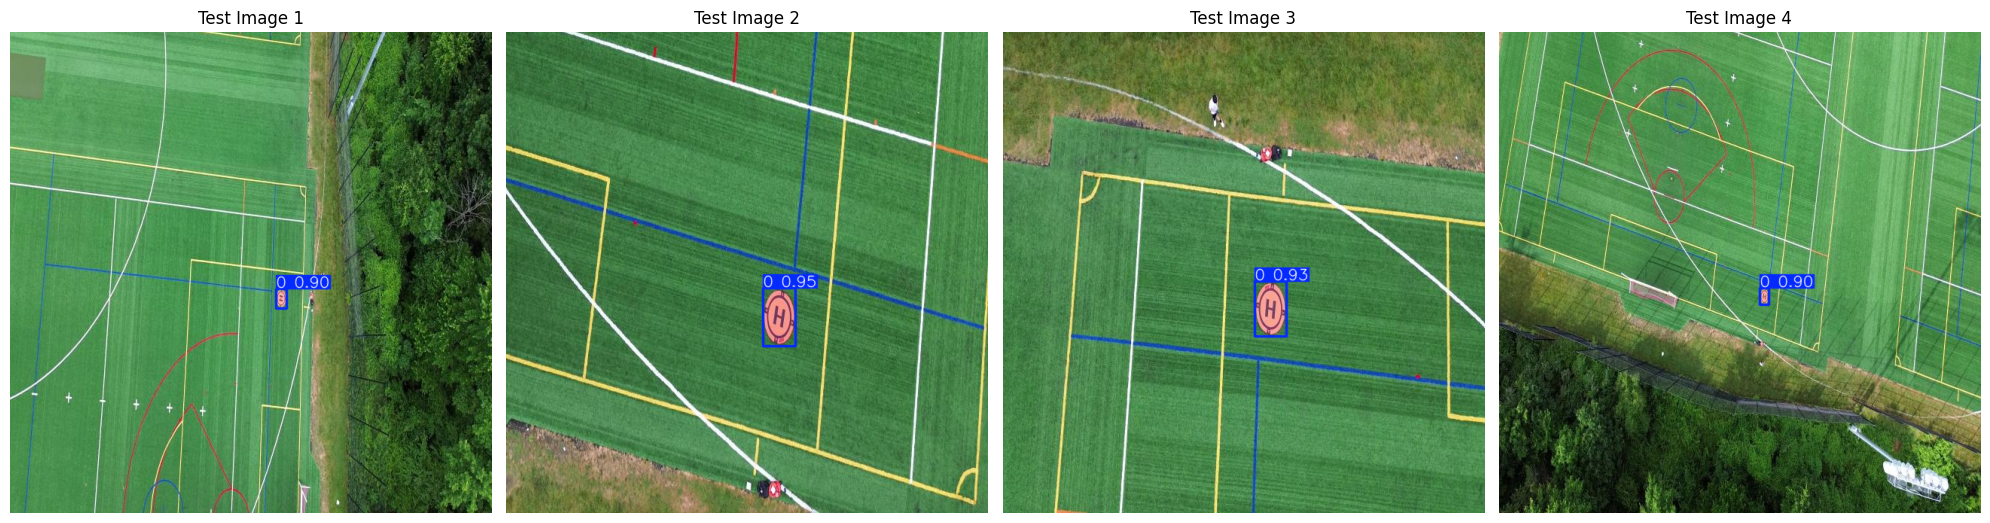

In [9]:
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO(best_weight_path)

val_images = glob.glob("valid/images/*.jpg")[:4]

if not val_images:
    print("No JPG images found. Checking for PNGs...")
    val_images = glob.glob("valid/images/*.png")[:4]

plt.figure(figsize=(20, 10))

for i, img_path in enumerate(val_images):

    results = model(img_path, verbose=False)

    annotated_img = results[0].plot()

    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 4, i+1)
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title(f"Test Image {i+1}")

plt.tight_layout()
plt.show()

#Testing fully

In [10]:
import glob
from ultralytics import YOLO

weight_files = glob.glob("**/best.pt", recursive=True)
yaml_files = glob.glob("**/data.yaml", recursive=True)

if not weight_files or not yaml_files:
    print("Could not find 'best.pt' or 'data.yaml'.")
else:
    best_weight_path = weight_files[0]
    data_yaml_path = yaml_files[0]

    print(f"Loading Model: {best_weight_path}")
    print(f"Loading Dataset: {data_yaml_path}\n")

    model = YOLO(best_weight_path)

    print("Running full validation suite")
    metrics = model.val(data=data_yaml_path)

Loading Model: runs/detect/Aethrone_Landing/landing_pad_model/weights/best.pt
Loading Dataset: Drone-Landing-Pad-Recognition-1/data.yaml

Running full validation suite
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1884.7±504.6 MB/s, size: 83.7 KB)
val: Scanning /content/valid/labels... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 2.3Kit/s 0.1s
val: New cache created: /content/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.3it/s 3.1s
                   all        150        150          1          1      0.995      0.933
Speed: 3.7ms preprocess, 5.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val


#Metrics to measure

In [11]:
precision = metrics.box.p[0]
recall = metrics.box.r[0]
map50 = metrics.box.map50
map50_95 = metrics.box.map

print(f"Precision:  {precision:.4f}  (How often is the model right when it guesses?)")
print(f"Recall:     {recall:.4f}  (How many of the total landing pads did it find?)")
print(f"mAP@50:     {map50:.4f}  (The golden metric for object detection)")
print(f"mAP@50-95:  {map50_95:.4f}  (The strict metric for exact bounding box placement)")

Precision:  0.9996  (How often is the model right when it guesses?)
Recall:     1.0000  (How many of the total landing pads did it find?)
mAP@50:     0.9950  (The golden metric for object detection)
mAP@50-95:  0.9335  (The strict metric for exact bounding box placement)
